In [2]:
## Load my files ##
import sys
sys.path.append('..')
from utils import get_sequence

## Load standard files ##
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.optim.lr_scheduler as lr_scheduler
from torch import from_numpy as tnsr
from scipy.stats import bernoulli
import torch.nn as nn
import numpy as np
import pandas as pd
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import cdist as dist
from sklearn.metrics.pairwise import cosine_similarity
from scipy.signal import find_peaks
from sklearn.manifold import MDS, TSNE 
from matplotlib import cm

In [3]:
class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers=1, token_size=7):
        super(RNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.RNN(input_size, hidden_size, num_layers, batch_first=True, nonlinearity='relu')
        self.fc1 = nn.Linear(hidden_size, token_size)
        
    def forward(self, x, hw=None, short_term_memory=None):
        if hw is None:
            out, hw = self.rnn(x)
        else:   
            out, hw = self.rnn(x, hw)
            
        out = self.fc1(out[:,-1,:])
        return out, hw

In [4]:
def compute_geodesic(hidden1, hidden2):

    total_layers = len(hidden1)
    w = 0

    for ii in range(total_layers):
        w_ = np.array(dist( hidden1[ii], hidden2[ii], 'cosine'))
        w += w_
           
    return w[0][0]/total_layers

In [5]:
class Dataset_converter(Dataset):
    def __init__(self, data, token_size, working_memory=1, short_term_memory=8):
        
        one_hot_encoded = np.zeros((len(data), token_size), dtype=float)
        for ii, token in enumerate(data):
            one_hot_encoded[ii,ord(token)-65] = 1
        
        self.X = np.zeros((((len(data)-working_memory-short_term_memory)), short_term_memory, token_size*working_memory))
        self.y = np.zeros((((len(data)-working_memory-short_term_memory)), token_size))

        for ii in range(self.X.shape[0]):
            for jj in range(self.X.shape[1]):
                for kk in range(working_memory):
                    self.X[ii,jj,kk*token_size:(kk+1)*token_size] = \
                    one_hot_encoded[ii+jj+kk,:]
                    
            self.y[ii] = \
                one_hot_encoded[ii+jj+kk+1,:]

        self.X = tnsr(self.X).float()
        self.y = tnsr(self.y).float()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [6]:
total_samples = 60000
working_memory = 1
short_term_memory = 7
n_community = 2
n_members = 3
node = 10
layer = 1
lr = 4e-4

token_size = n_community*n_members+1
input_size = token_size*working_memory

train_data = get_sequence(total_samples, n_community, n_members)#, train_percent=(1/3.0))
# train_data = ''

# for ii in range(len(train_data_)):
#      if train_data_[ii] == 'G':
#           continue
#      else:
#           train_data = train_data + train_data_[ii]


model = RNN(input_size, node, num_layers=layer, token_size=token_size)

data_set = Dataset_converter(train_data, token_size, working_memory, short_term_memory)
train_loader = DataLoader(data_set, batch_size=1, shuffle=False)

optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.95)
criterion = torch.nn.CrossEntropyLoss()

total = 0
correct_train = np.zeros(1000,dtype=float)
train_acc = []
for (X_train, y_train) in train_loader:
    optimizer.zero_grad()

    if total == 0:
        predicted_y, hidden = model(X_train, short_term_memory=short_term_memory)
    else:
        predicted_y, hidden = model(X_train, hw=memory, short_term_memory=short_term_memory)

    
    loss = criterion(predicted_y, y_train)
    loss.backward(retain_graph=True)
    optimizer.step()

    with torch.no_grad():
        memory = hidden.clone()
        true_y = y_train.argmax(axis=1)
        estimated_y = predicted_y.argmax(axis=1)

        total += 1
        if true_y == estimated_y:
            correct_train[total%1000] = 1
        else:
            correct_train[total%1000] = 0


        train_acc.append(
            np.sum(correct_train)/total if total<1000 else np.sum(correct_train)/1000
        )
        
        if total%1000 == 0:
            print(f'Iter : {total+1}, loss: {loss:.4f}, train accuracy: {train_acc[-1]:.4f}')


Iter : 1001, loss: 1.8469, train accuracy: 0.2390
Iter : 2001, loss: 1.9843, train accuracy: 0.4150
Iter : 3001, loss: 1.8183, train accuracy: 0.5340
Iter : 4001, loss: 1.4437, train accuracy: 0.5780
Iter : 5001, loss: 1.4252, train accuracy: 0.5940
Iter : 6001, loss: 0.2415, train accuracy: 0.6310
Iter : 7001, loss: 0.1631, train accuracy: 0.6090
Iter : 8001, loss: 0.0590, train accuracy: 0.6250
Iter : 9001, loss: 0.0757, train accuracy: 0.6510
Iter : 10001, loss: 0.3750, train accuracy: 0.6800
Iter : 11001, loss: 0.2010, train accuracy: 0.6880
Iter : 12001, loss: 0.1166, train accuracy: 0.6900
Iter : 13001, loss: 0.0974, train accuracy: 0.6950
Iter : 14001, loss: 0.0580, train accuracy: 0.6990
Iter : 15001, loss: 0.0725, train accuracy: 0.6900
Iter : 16001, loss: 0.2011, train accuracy: 0.6940
Iter : 17001, loss: 0.0553, train accuracy: 0.6820
Iter : 18001, loss: 0.0182, train accuracy: 0.6960
Iter : 19001, loss: 0.0389, train accuracy: 0.6870
Iter : 20001, loss: 0.0380, train accura

In [7]:
compressor_sample = 2000

data_compressor = get_sequence(compressor_sample, n_community, n_members, train=True)#, train_percent=(1/3.0))

# data_compressor = ''

# for ii in range(len(data_compressor_)):
#      if data_compressor_[ii] == 'G':
#           continue
#      else:
#           data_compressor = data_compressor + data_compressor_[ii]

data_set_compressor =  Dataset_converter(data_compressor, token_size, working_memory, short_term_memory)
compressor_loader = DataLoader(data_set_compressor, batch_size=1, shuffle=False) 
hidden_states = []

ii = 0
dis = [0]
# community = ''
com = []

with torch.no_grad():
    for X, _ in compressor_loader:
        if X[0][-1].argmax()<3:
            com.append('A')
        elif X[0][-1].argmax()<6:
            com.append('D')
        else:
            com.append('G')
            
        if ii==0:
            id, hw = model(X)
            id_current = hw
            hidden_states.append(hw[0][0])
            # community = tokens[torch.argmax(X[0])]
        else:
            id, hw = model(X, hw=hw)
            id_current = hw
            hidden_states.append(hw[0][0])
            
            if ii>=1:
                dis.append(compute_geodesic(prev_id, id_current))
                # print(dis)
                # if dis[-1] >0.407:
                #     # print(dis, tokens[torch.argmax(X[0])])
                #     community += tokens[torch.argmax(X[0])]
                    
            
        prev_id = id_current
        ii += 1

In [8]:
dis_array = np.array(dis)
# threshold = np.quantile(dis_array, .8)
# peaks = find_peaks(dis_array, .7)[0]
peaks = [-100] 
threshold = 0.2
prev_dis = 1

for ii, dis in enumerate(dis_array):
    if prev_dis - dis >= threshold and peaks[-1]!=ii-2:
        peaks.append(ii-1)
    
    prev_dis = dis 

peaks.pop(0)
mask = np.zeros(dis_array.shape, dtype=int)
mask[peaks] = 1
# mask = ((dis_array>threshold)*1)

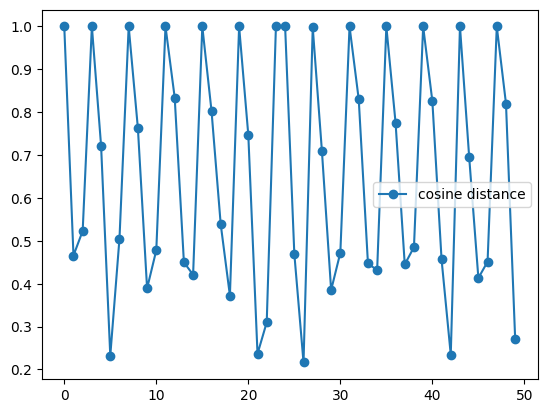

In [9]:
span = 50
plt.plot(dis_array[-span:], '-o', label='cosine distance')
# plt.plot(mask[-span:], c='k', label = 'mask')
plt.legend()

In [24]:
D = np.zeros((len(hidden_states), len(hidden_states)), dtype=float)

for ii in range(len(hidden_states)):
    for jj in range(len(hidden_states)):
        D[ii,jj] = dist([hidden_states[ii]], [hidden_states[jj]], 'cosine')[0][0]


embedding = MDS(n_components=4, dissimilarity='precomputed', random_state=101)
X_transformed = embedding.fit_transform(D)

In [25]:
data = pd.DataFrame()

for ii in range(4):
    data['component'+str(ii+1)] = X_transformed[:,ii]

data['color'] = com
# sns.set_context('talk')

# for ii in range(len(X_transformed)):
#     plt.plot(X_transformed[ii,0], X_transformed[ii,1], c=clr[com[ii]-1], marker='o')

# plt.xlabel('Component 1')
# plt.ylabel('Component 2')

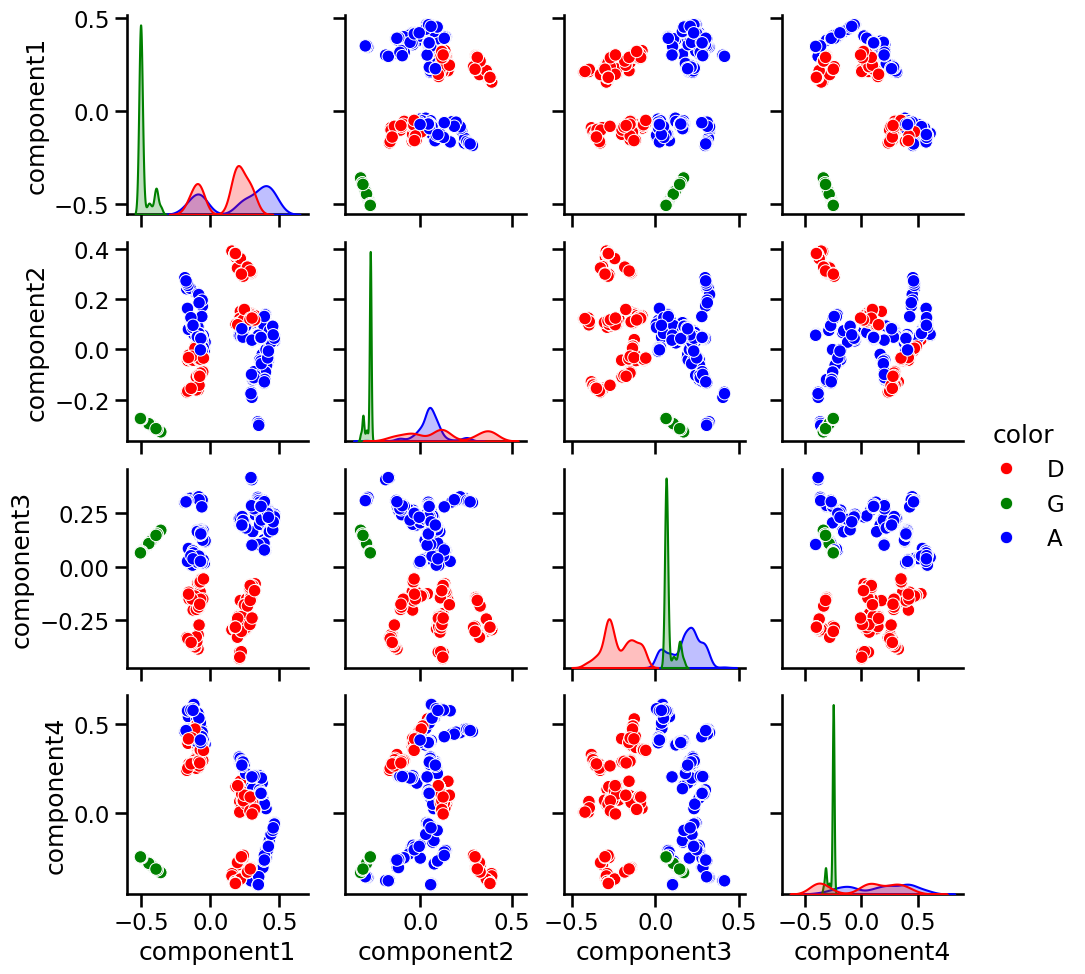

In [26]:
sns.pairplot(data, hue="color", palette=['r','g','b'])

In [170]:
n_components = [2,3,4,5]
stresses = []

for n_component in tqdm(n_components):
    embedding = MDS(n_components=n_component, dissimilarity='precomputed', random_state=101)
    X_transformed = embedding.fit_transform(D)
    stresses.append(embedding.stress_)


100%|██████████| 4/4 [01:06<00:00, 16.50s/it]


Text(0, 0.5, 'Stress')

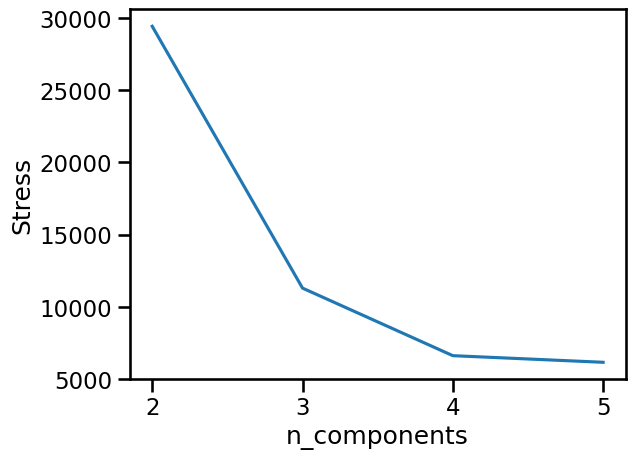

In [172]:
sns.set_context('talk')

plt.plot(n_components, stresses)

plt.xticks(n_components)
plt.xlabel('n_components')
plt.ylabel('Stress')

In [10]:
D = np.zeros((len(hidden_states), len(hidden_states)), dtype=float)

for ii in range(len(hidden_states)):
    for jj in range(len(hidden_states)):
        D[ii,jj] = dist([hidden_states[ii]], [hidden_states[jj]], 'cosine')[0][0]


In [15]:
n_components = [2,3,4,5,6,7,8,9,10]
stresses = []

for n_component in tqdm(n_components):
    embedding = TSNE(n_components=n_component, random_state=101, method='exact', n_jobs=-1)
    X_transformed = embedding.fit_transform(np.array(hidden_states))
    stresses.append(embedding.kl_divergence_)


100%|██████████| 9/9 [14:12<00:00, 94.71s/it] 


Text(0, 0.5, 'KL div')

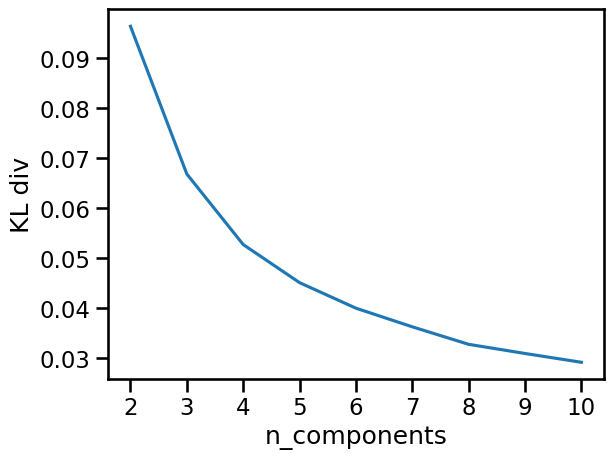

In [17]:
sns.set_context('talk')

plt.plot(n_components, stresses)

plt.xticks(n_components)
plt.xlabel('n_components')
plt.ylabel('KL div')